In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
import matplotlib.pyplot as plt
#manually type the dataset as a dectionary
data ={
    'student-ID':[1001, 1002, 1003, 1004, 1005, 1001, 1006, 1007, 1008, 1009],
    'county': ['Nakuru', 'Narok', 'Nakuru', 'Narok', 'Kakamega', 'Nakuru', 'Nairobi', None, 'Narok', 'Nakuru'],
    'Study_Hours_Per_Week': [15, 8, 20, None, 12, 15, 30, 10, 25, 18],
    'Attendance_Percent':[85, 60, 92, 55, 78, 85, 95, 65, 88, None], 
    'Fee_Balance_Ksh':[0, 15000, 0, 25000, 5000, 0, 0, 18000, 2000, 12000],
    'Prvious_Grade':[72, 48, 85, 45, 65, 72, 90, 50, 82, 58],
    'Student_TYpe':['Regular', 'Regular', 'Scholarship', 'Regular', 'Scholarship', 'Regular', 'Regular', 'Scholarship', 'Regular', 'Regular'],
    'Academic_Risk':[0, 1, 0, 1, 0, 0, 0, 1, 0, 1]
}
#Converts the dataset dictionary into panda Data Frame

df = pd.DataFrame(data)


#to diplay all the rows and columns of the Panda Dataframe with trancation(cutting)
pd.set_option('display.max_row', None)
pd.set_option('display.max_columns', None)
#to display the dataframe
df

,student-ID,county,Study_Hours_Per_Week,Attendance_Percent,Fee_Balance_Ksh,Prvious_Grade,Student_TYpe,Academic_Risk
0,1001,Nakuru,15.0,85.0,0,72,Regular,0
1,1002,Narok,8.0,60.0,15000,48,Regular,1
2,1003,Nakuru,20.0,92.0,0,85,Scholarship,0
3,1004,Narok,NaN,55.0,25000,45,Regular,1
4,1005,Kakamega,12.0,78.0,5000,65,Scholarship,0
5,1001,Nakuru,15.0,85.0,0,72,Regular,0
6,1006,Nairobi,30.0,95.0,0,90,Regular,0
7,1007,NaN,10.0,65.0,18000,50,Scholarship,1
8,1008,Narok,25.0,88.0,2000,82,Regular,0
9,1009,Nakuru,18.0,NaN,12000,58,Regular,1


In [18]:
#----- DATA CLEANING -----
#to handel duplicate valuse
df=df.drop_duplicates()

#To handel th missing vales 

#missing valuse in county
df['county']=df['county'].fillna(df['county'].mode()[0])

#missing valuse in study hours per week
df['Study_Hours_Per_Week']=df['Study_Hours_Per_Week'].fillna(df['Study_Hours_Per_Week'].median())

#missing valuse in Attendances perrcent
df['Attendance_Percent']=df['Attendance_Percent'].fillna(df['Attendance_Percent'].median())

#Missing valuse in fee balance
df['Fee_Balance_Ksh']=df['Fee_Balance_Ksh'].fillna(df['Fee_Balance_Ksh'].median())

#MIssing valuse in privious grade
df['Prvious_Grade']=df['Prvious_Grade'].fillna(df['Prvious_Grade'].median())

#Missing valuse instudent type
df['Student_TYpe']=df['Student_TYpe'].fillna(df['Student_TYpe'].mode()[0])

#Missing valuse in accademic Risk
df['Academic_Risk']=df['Academic_Risk'].fillna(df['Academic_Risk'].mode()[0])

#check for missing values
df.isnull().sum()

df

#---- Resons for uing median an mode -----
#median is used in Numerical fields becouse it is resistant to outliers
#mode is used in categorical fields becouse it can not be averaged or found with a median


,student-ID,county,Study_Hours_Per_Week,Attendance_Percent,Fee_Balance_Ksh,Prvious_Grade,Student_TYpe,Academic_Risk
0,1001,Nakuru,15.0,85.0,0,72,Regular,0
1,1002,Narok,8.0,60.0,15000,48,Regular,1
2,1003,Nakuru,20.0,92.0,0,85,Scholarship,0
3,1004,Narok,16.5,55.0,25000,45,Regular,1
4,1005,Kakamega,12.0,78.0,5000,65,Scholarship,0
6,1006,Nairobi,30.0,95.0,0,90,Regular,0
7,1007,Nakuru,10.0,65.0,18000,50,Scholarship,1
8,1008,Narok,25.0,88.0,2000,82,Regular,0
9,1009,Nakuru,18.0,81.5,12000,58,Regular,1


Summary Statistics


,Study_Hours_Per_Week,Attendance_Percent,Fee_Balance_Ksh,Prvious_Grade,Academic_Risk
count,9.000000,9.000000,9.000000,9.000000,9.000000
mean,17.166667,77.722222,8555.555556,66.111111,0.444444
std,7.088723,14.437605,9275.116052,17.010618,0.527046
min,8.000000,55.000000,0.000000,45.000000,0.000000
25%,12.000000,65.000000,0.000000,50.000000,0.000000
50%,16.500000,81.500000,5000.000000,65.000000,0.000000
75%,20.000000,88.000000,15000.000000,82.000000,1.000000
max,30.000000,95.000000,25000.000000,90.000000,1.000000


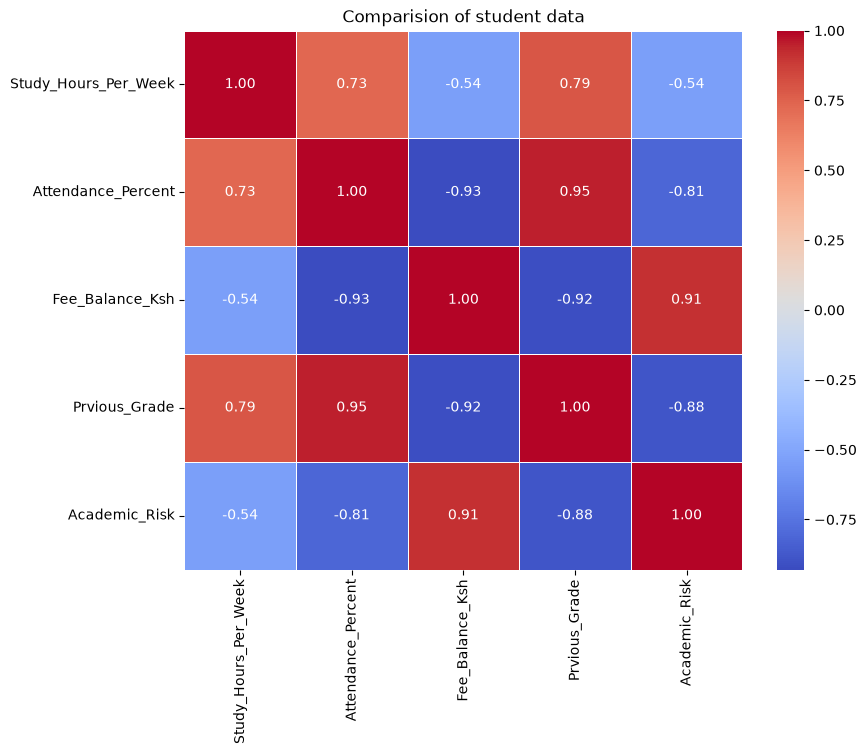

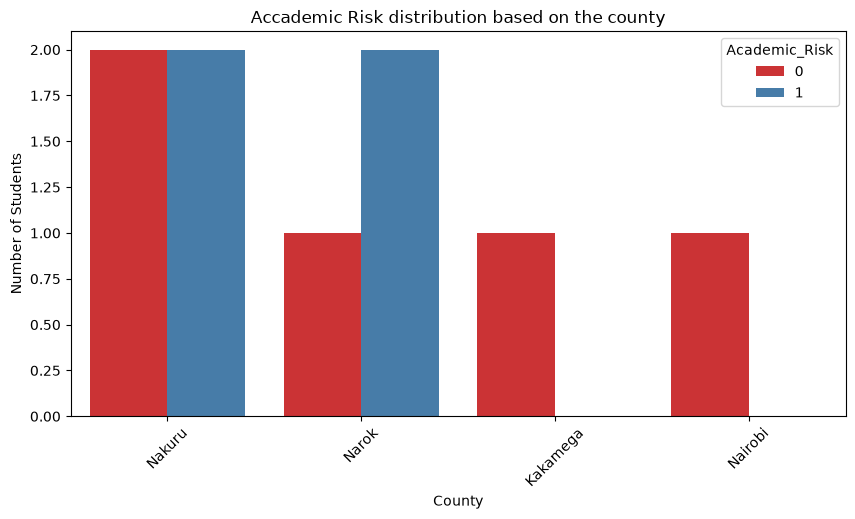

In [19]:
#----Data Analysis----
#summary statistics for numerical variables
numerical_cols = [
    "Study_Hours_Per_Week",
    "Attendance_Percent",
    "Fee_Balance_Ksh",
    "Prvious_Grade",
    "Academic_Risk",
]
# Creating the titel
print("Summary Statistics")
display(df[numerical_cols].describe())

# Creating the heatmap
# creating the ploting area
plt.figure(figsize=(9, 7))

#Finding the correlational confflicienyt between the listed filed in the numerical_cols
correlation = df[numerical_cols].corr()

# Drawing the heatmap
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# sns.heatmap-Drawing thge grid of squares
# correlation-the values which will be used in the heatmap
# annot=True-write the decx9imal values
# cmap="coolwarm"-set th colour scheme
# fmt=".2f"-set that only 2 decimal places will be displayed
# linewidth=0.5-set a spacing between the gride

# Adding a Title
plt.title("Comparision of student data")
plt.show()

# ---- Using the categorical data in Analyzingusing the Groupbys

# to set the canvase size
plt.figure(figsize=(10, 5))

# Drawing the grouped bar chart
sns.countplot(data=df, x="county", hue="Academic_Risk", palette="Set1")
# sns.countplot-A seaborn function that automatical count jow many row fall into each category
# data =df - tells python to use the data from the dataframe named df
# x="county"-put th county on the x-axies
# hue="Acdmic_Risk"-markes each bar inside each  county group based on the student Accadmic_Risk
# palette="Set1"- applices a disting visual color(Set1)

# --- Creating a title  and axis labels

# giving the chart a title on the top area
plt.title("Accademic Risk distribution based on the county") 
plt.xlabel("County") # x axis lable
plt.ylabel("Number of Students") # Y axis lable
plt.xticks(rotation=45) # To rotate the x axis lable 45 degres

# display the chart
plt.show()

In [20]:
#---- Feature Engineering -----
#Attendaces category
# creating a ranges
    #0 - 74 low
    # 75 - 89 Median
    # 90 - 100 high
attendance_bins =[-1, 74, 89, 100]
#give the ranges text
attendance_labels =['Low', 'Median', 'High']

df["Attendance_Category"] = pd.cut(
    df['Attendance_Percent'],
    bins=attendance_bins,
    labels = attendance_labels
)
#df['attendance_category]-creating a new column
# pd.cut()- a build in Pandas function that takes you numerical and sort it to correct bin bracket
#Attendance_percent- column sort every student attendace
# bin=attendance_bins- it tell the pd.cut() function where to slice or divide your numerical data
# label = attendance.labels- it tell Pandas what name to givfe to the slices you just created with the bins

# Fee Balance indicator
#if they own money is 1 and if they have no balance 0
df['Fee_Balance_Analices']=np.where(df['Fee_Balance_Ksh']> 0, 1, 0)

#Display the update dtataframe with the new features
#this is to display the title of the table
print("Student Analitics with the feature Engineering")
# the filed to be in the table
display(df[['student-ID',
            'Attendance_Percent',
            'Attendance_Category',
            'Fee_Balance_Ksh',
            'Fee_Balance_Analices']])

Student Analitics with the feature Engineering


,student-ID,Attendance_Percent,Attendance_Category,Fee_Balance_Ksh,Fee_Balance_Analices
0,1001,85.0,Median,0,0
1,1002,60.0,Low,15000,1
2,1003,92.0,High,0,0
3,1004,55.0,Low,25000,1
4,1005,78.0,Median,5000,1
6,1006,95.0,High,0,0
7,1007,65.0,Low,18000,1
8,1008,88.0,Median,2000,1
9,1009,81.5,Median,12000,1


In [21]:
#--- Encoder and standerzation
# converting the categorical values to numerical values (0 and 1)
df_encoded = pd.get_dummies(df, columns=['county', 'Student_TYpe'], drop_first=True)

# display thye encode table
display(df_encoded)

#Standardzing numerical values 

#selecting the numerical filed which will be standardized
num_cols = ['Study_Hours_Per_Week',
            'Attendance_Percent',
            'Fee_Balance_Ksh',
            'Prvious_Grade']

#initializing the scale and applying it
scale = StandardScaler()
df[num_cols] = scale.fit_transform(df[num_cols])

# to display the output
display(df)

,student-ID,Study_Hours_Per_Week,Attendance_Percent,Fee_Balance_Ksh,Prvious_Grade,Academic_Risk,Attendance_Category,Fee_Balance_Analices,county_Nairobi,county_Nakuru,county_Narok,Student_TYpe_Scholarship
0,1001,15.0,85.0,0,72,0,Median,0,False,True,False,False
1,1002,8.0,60.0,15000,48,1,Low,1,False,False,True,False
2,1003,20.0,92.0,0,85,0,High,0,False,True,False,True
3,1004,16.5,55.0,25000,45,1,Low,1,False,False,True,False
4,1005,12.0,78.0,5000,65,0,Median,1,False,False,False,True
6,1006,30.0,95.0,0,90,0,High,0,True,False,False,False
7,1007,10.0,65.0,18000,50,1,Low,1,False,True,False,True
8,1008,25.0,88.0,2000,82,0,Median,1,False,False,True,False
9,1009,18.0,81.5,12000,58,1,Median,1,False,True,False,False


,student-ID,county,Study_Hours_Per_Week,Attendance_Percent,Fee_Balance_Ksh,Prvious_Grade,Student_TYpe,Academic_Risk,Attendance_Category,Fee_Balance_Analices
0,1001,Nakuru,-0.324191,0.534663,-0.978374,0.367189,Regular,0,Median,0
1,1002,Narok,-1.371575,-1.301965,0.736957,-1.129279,Regular,1,Low,1
2,1003,Nakuru,0.423941,1.048918,-0.978374,1.177776,Scholarship,0,High,0
3,1004,Narok,-0.099751,-1.669290,1.880512,-1.316338,Regular,1,Low,1
4,1005,Kakamega,-0.773070,0.020407,-0.406597,-0.069281,Scholarship,0,Median,1
6,1006,Nairobi,1.920205,1.269314,-0.978374,1.489540,Regular,0,High,0
7,1007,Nakuru,-1.072323,-0.934639,1.080024,-1.004573,Scholarship,1,Low,1
8,1008,Narok,1.172073,0.755058,-0.749664,0.990717,Regular,0,Median,1
9,1009,Nakuru,0.124689,0.277535,0.393891,-0.505751,Regular,1,Median,1


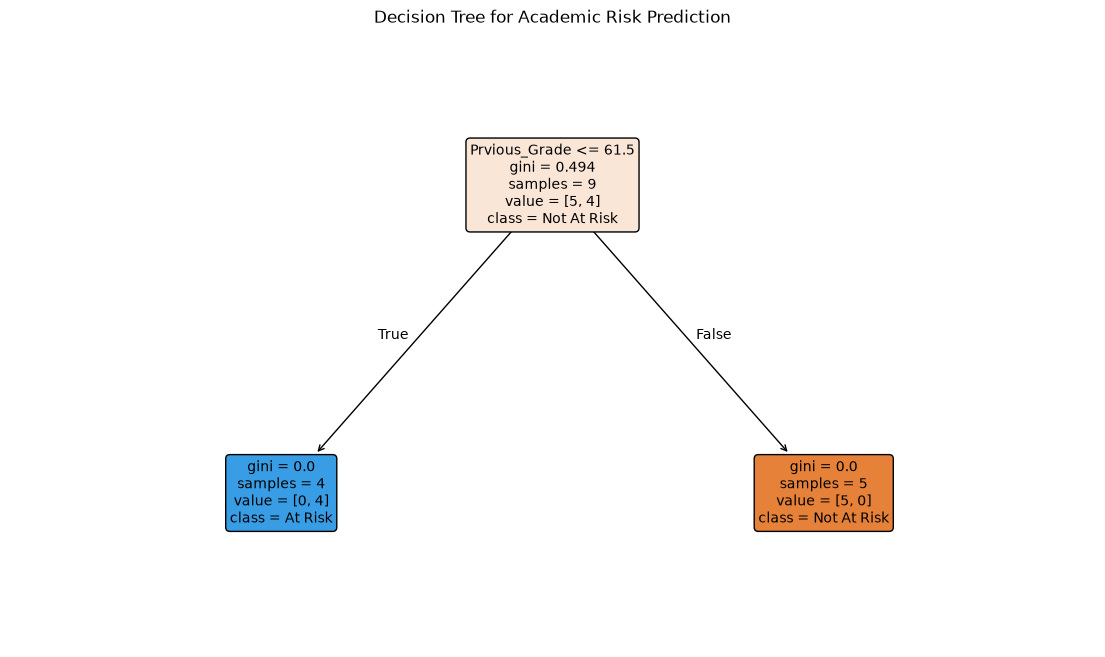

In [25]:
# ---- Desition Tree  and Graphviz -----
#Defining Features
x = df_encoded.drop(columns=[
    'student_ID',          
    'Academic_Risk',
    'Attendance_Category'
], errors='ignore')
y = df_encoded['Academic_Risk']
#x(input)-information used by the model to learn
# df.encoded - it takes you dataframe and removes columns thata shouldn't be used for predicting
# student-ID - just a as unique identify
# Academic_Risk - what is being predicted and can not be used as an input
# y(output)- the extra column you want to predict

#traning the decision tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(x, y)
# decisisonTreeClassifier - is an  machin learning algorithm imported from scikit-learn
# max_depth=3 - limits the tree to a maximum of 3 level deep and keeps the tree simple
# random_state=42 -make sure if you run the code angine you will still get the same tree structre
# .fit(x, y) - a machine learning training stap where the algorith, looks at  the feature(x) and learning the  patterns that lead to the target

# Exporting to Graphviz DOT fromat
#this translate the trained decision tree into unuiversal text format
# Exporting to Graphviz DOT format (Clean and correct)
plt.figure(figsize=(14, 8))
plot_tree(
    clf,
    feature_names=x.columns,
    class_names=['Not At Risk', 'At Risk'],
    filled=True,
    rounded=True,
    fontsize=10,
)
#feature_name=x.columns- labels the split point in the tree with your actual column/feature name
#class_name=['Not At Risk], 'At Risk']- gives friedly text name to the 2 possibel outcome of your target variable
# fill=True, rounded=True - make the resulting diagram look clean colorful and easy to read

#Displaying The tree
plt.title("Decision Tree for Academic Risk Prediction")
plt.show()

# grahviz.sources(*dot_data)- converting the text data from the previous step into visual graph abject
# Dsipaly(graph)- Display the flowehart diagram directly in you notebook

